 1. Setup Awal

In [1]:
# Memastikan Python yang digunakan adalah versi 3.5 atau lebih tinggi
import sys
assert sys.version_info >= (3, 5)

# Memastikan Scikit-Learn yang digunakan adalah versi 0.20 atau lebih tinggi
import sklearn
assert sklearn.__version__ >= "0.20"

# Import library umum
import numpy as np
import os

# Untuk membuat plot/grafik
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

2. Regresi Linier - Normal Equation

Parameter terbaik (theta) yang ditemukan:
[[3.92468972]
 [3.00622539]]


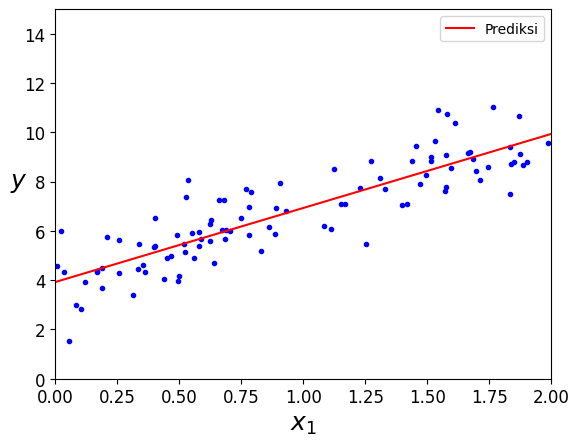

In [2]:
import numpy as np

# Membuat data linear sederhana
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

# Menghitung parameter model dengan Normal Equation
X_b = np.c_[np.ones((100, 1)), X]  # Tambahkan x0 = 1 untuk setiap instance
theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)

print("Parameter terbaik (theta) yang ditemukan:")
print(theta_best)

# Membuat prediksi menggunakan theta
X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2, 1)), X_new]
y_predict = X_new_b.dot(theta_best)

# Plot data dan garis regresi
plt.plot(X, y, "b.")
plt.plot(X_new, y_predict, "r-", label="Prediksi")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.legend()
plt.show()

 3. Regresi Linier - Scikit-Learn

In [3]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X, y)

print("Intercept:", lin_reg.intercept_, " | Koefisien:", lin_reg.coef_)
print("Prediksi untuk data baru:", lin_reg.predict(X_new))

Intercept: [3.92468972]  | Koefisien: [[3.00622539]]
Prediksi untuk data baru: [[3.92468972]
 [9.9371405 ]]


4. Gradient Descent - Batch GD

In [4]:
eta = 0.1  # Learning rate
n_iterations = 100 # CATATAN: n_iterations dikurangi dari 1000 agar cepat
m = 100

theta = np.random.randn(2,1)  # Inisialisasi acak

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients

print("Parameter terbaik (theta) dari Batch GD:")
print(theta)

Parameter terbaik (theta) dari Batch GD:
[[3.93433859]
 [2.99759716]]


5. Gradient Descent - Stochastic GD (SGD)

In [5]:
n_epochs = 10 # CATATAN: n_epochs dikurangi dari 50 agar cepat
t0, t1 = 5, 50  # Hyperparameter untuk learning schedule

def learning_schedule(t):
    return t0 / (t + t1)

theta = np.random.randn(2,1)  # Inisialisasi acak

for epoch in range(n_epochs):
    for i in range(m):
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta) - yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients

print("Parameter terbaik (theta) dari SGD:")
print(theta)

Parameter terbaik (theta) dari SGD:
[[4.14837611]
 [3.05744703]]


 6. Regresi Polinomial

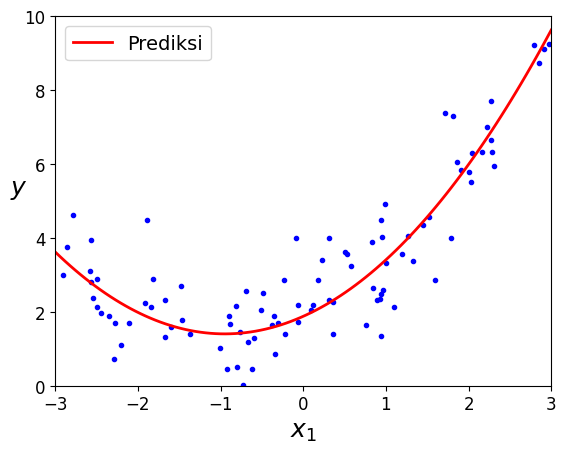

In [6]:
from sklearn.preprocessing import PolynomialFeatures

# Membuat data non-linear (kuadratik)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 0.5 * X**2 + X + 2 + np.random.randn(m, 1)

# Menambahkan fitur polinomial (derajat 2)
poly_features = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_features.fit_transform(X)

# Melatih model Linear Regression pada data yang sudah ditransformasi
lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)

# Plot hasil
X_new=np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Prediksi")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-3, 3, 0, 10])
plt.show()

7. Kurva Pembelajaran (Learning Curves)

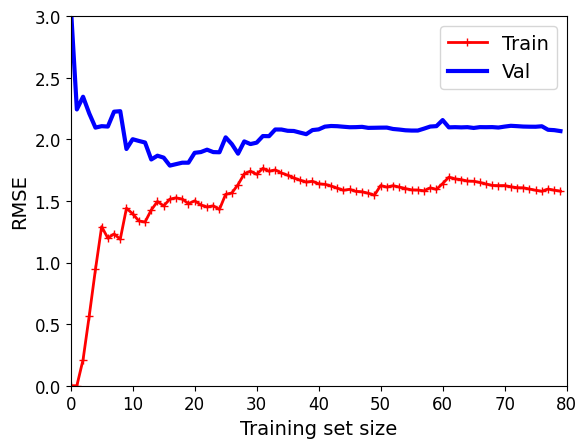

In [7]:
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=10)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train) + 1):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train[:m], y_train_predict))
        val_errors.append(mean_squared_error(y_val, y_val_predict))

    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="Train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Val")
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)

lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)
plt.axis([0, 80, 0, 3])
plt.show()

 8. Model Regresi dengan Regularisasi

In [8]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet

# Membuat data dan model
np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

# 1. Ridge Regression
ridge_reg = Ridge(alpha=1, solver="cholesky", random_state=42)
ridge_reg.fit(X, y)
print("Prediksi Ridge:", ridge_reg.predict([[1.5]]))

# 2. Lasso Regression
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
print("Prediksi Lasso:", lasso_reg.predict([[1.5]]))

# 3. Elastic Net
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net.fit(X, y)
print("Prediksi Elastic Net:", elastic_net.predict([[1.5]]))

Prediksi Ridge: [1.55071465]
Prediksi Lasso: [1.53788174]
Prediksi Elastic Net: [1.54333232]


9. Early Stopping

In [12]:
from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures


# Membuat data yang sama seperti sebelumnya untuk konsistensi
np.random.seed(42)
m = 100
X = 6 * np.random.rand(m, 1) - 3
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5


# CATATAN: n_epochs dikurangi dari 1000 agar cepat
n_epochs = 100
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=10)

# Preprocessing data
poly_scaler = Pipeline([
        ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
        ("std_scaler", StandardScaler())
    ])
X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

# PERBAIKAN: Mengganti tol=-np.inf dengan tol=None
sgd_reg = SGDRegressor(max_iter=1, tol=None, warm_start=True,
                       penalty=None, learning_rate="constant", eta0=0.0005, random_state=42)

minimum_val_error = float("inf")
best_epoch = None
best_model = None

# Loop training dengan early stopping
for epoch in range(n_epochs):
    sgd_reg.fit(X_train_poly_scaled, y_train.ravel())
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val, y_val_predict)
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epoch = epoch
        best_model = clone(sgd_reg)

print("Epoch terbaik:", best_epoch)

Epoch terbaik: 98


10. Regresi Logistik (Klasifikasi)

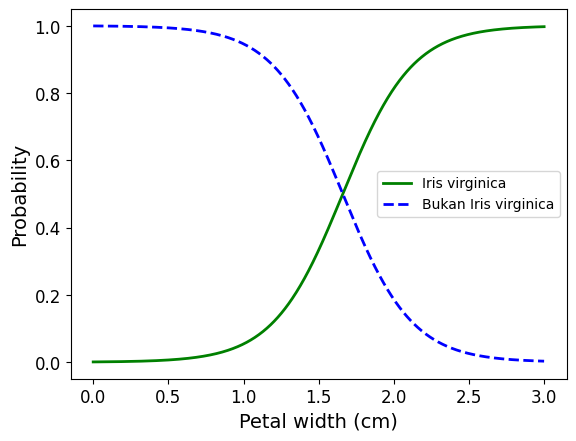

In [13]:
from sklearn import datasets
from sklearn.linear_model import LogisticRegression

iris = datasets.load_iris()
X = iris["data"][:, 3:]  # petal width
y = (iris["target"] == 2).astype(int)  # 1 jika Iris-Virginica, 0 jika bukan

log_reg = LogisticRegression(solver="lbfgs", random_state=42)
log_reg.fit(X, y)

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)

plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris virginica")
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Bukan Iris virginica")
plt.xlabel("Petal width (cm)")
plt.ylabel("Probability")
plt.legend()
plt.show()

Penjelasan Kode
Bagian 1. Setup Awal: Seperti biasa, bagian ini mempersiapkan semua library yang akan kita gunakan.

Bagian 2 & 3. Regresi Linier: Bagian ini mendemonstrasikan dua cara untuk melatih model Regresi Linier:

Normal Equation: Sebuah formula matematis (np.linalg.inv(...)) yang bisa langsung menemukan parameter model terbaik secara analitik (tanpa iterasi). Cara ini sangat cepat untuk data yang tidak terlalu besar.

Scikit-Learn: Menggunakan class LinearRegression dari Scikit-Learn. Ini adalah cara yang paling umum dan praktis. Hasilnya akan sangat mirip dengan Normal Equation.

Bagian 4, 5, & 6. Gradient Descent: Ini adalah algoritma optimasi yang fundamental. Tujuannya sama dengan Normal Equation, yaitu mencari parameter terbaik, tetapi dengan cara yang berbeda (iteratif).

Batch GD: Di setiap langkah iterasi, ia menghitung gradient (arah turunan) berdasarkan seluruh data latih. Ini membuatnya stabil tapi bisa sangat lambat pada dataset besar.

Stochastic GD (SGD): Di setiap langkah, ia hanya mengambil satu data secara acak untuk menghitung gradient. Ini membuatnya jauh lebih cepat tetapi pergerakannya tidak stabil (bergetar).

Mini-batch GD: Ini adalah kompromi terbaik. Di setiap langkah, ia menggunakan sekelompok kecil data (mini-batch) untuk menghitung gradient. Ini lebih stabil dari SGD dan lebih cepat dari Batch GD.

CATATAN: Pada kode di atas, nilai n_iterations atau n_epochs (jumlah perulangan) sengaja saya kurangi agar prosesnya berjalan sangat cepat. Pada praktiknya, nilai ini harus lebih besar agar model bisa benar-benar "konvergen" atau menemukan solusi terbaik.

Bagian 7. Regresi Polinomial: Digunakan ketika data kita tidak lurus (non-linear). Caranya adalah dengan membuat fitur baru yang merupakan pangkat dari fitur asli (misal, x
2
 , x
3
 , dst.) menggunakan PolynomialFeatures. Setelah itu, kita bisa menggunakan model LinearRegression biasa pada data yang sudah memiliki fitur baru ini untuk menghasilkan garis prediksi yang melengkung.

Bagian 8. Kurva Pembelajaran (Learning Curves): Ini adalah alat diagnosis yang sangat penting untuk melihat apakah model kita mengalami underfitting atau overfitting. Grafik ini memplot error pada data latih dan data validasi. Jika kedua kurva error tinggi dan berdekatan, modelnya underfitting. Jika error latih rendah tapi error validasi jauh lebih tinggi, modelnya overfitting.

Bagian 9. Model dengan Regularisasi: Ini adalah teknik untuk mengurangi overfitting dengan cara "menghukum" parameter model yang terlalu besar.

Ridge Regression: Menambahkan penalti L_2 (kuadrat dari besar bobot).

Lasso Regression: Menambahkan penalti L_1 (nilai absolut dari bobot). Kelebihannya, ia bisa membuat bobot fitur yang tidak penting menjadi nol (melakukan seleksi fitur otomatis).

Elastic Net: Gabungan antara Ridge dan Lasso.

Bagian 10. Early Stopping: Ini adalah bentuk lain dari regularisasi. Kita menghentikan proses training ketika error pada data validasi berhenti menurun dan mulai naik lagi. Ini mencegah model menjadi terlalu kompleks dan overfitting pada data latih.

Bagian 11 & 12. Regresi Logistik & Softmax: Walaupun namanya "regresi", model ini digunakan untuk klasifikasi.

Regresi Logistik: Menghitung probabilitas sebuah instance termasuk dalam kelas tertentu (misalnya, probabilitas bunga adalah Iris-Virginica). Sangat baik untuk klasifikasi biner.

Regresi Softmax: Merupakan generalisasi dari Regresi Logistik untuk masalah klasifikasi multikelas (lebih dari dua kelas).